In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

from dotenv import load_dotenv

import warnings
warnings.simplefilter(action="ignore", category=pd.errors.SettingWithCopyWarning)

# Load and clear data

In [2]:
load_dotenv()

data = pd.read_csv(os.getenv('DATA_PATH'))

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 492800 entries, 0 to 492799
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   message_id  492800 non-null  object
 1   text        492800 non-null  object
 2   item_title  492800 non-null  object
dtypes: object(3)
memory usage: 11.3+ MB


In [4]:
# check for duplicates and missing values in messages
print(f"number of duplicate rows: {data['text'].duplicated().sum()}")
print(f"number of missing values: {data['text'].isnull().sum()}")

number of duplicate rows: 131200
number of missing values: 0


In [5]:
# clear the text from duplicates
deduplicated_data = data.drop_duplicates(subset=['text'], keep='first')

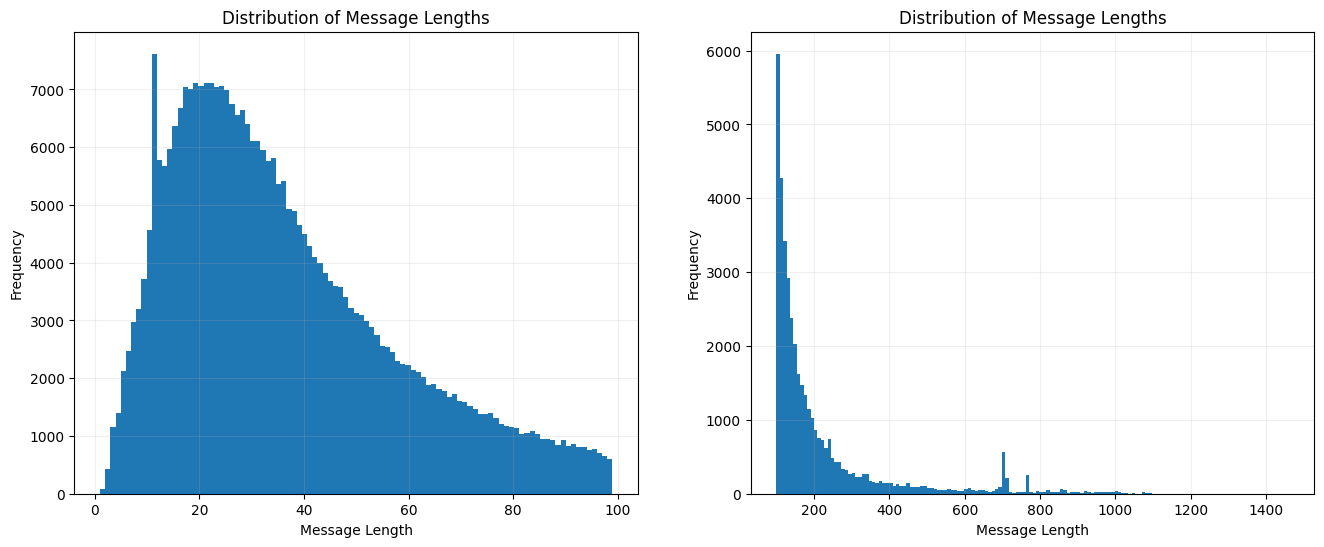

In [6]:
# check length of messages
axes = plt.subplots(1, 2, figsize=(16, 6))
# plot the distribution of message lengths for messages shorter than 100 characters
axes[1][0].hist(deduplicated_data['text'][deduplicated_data['text'].str.len() < 100].str.len(), bins=99)
axes[1][0].set_xlabel('Message Length')
axes[1][0].set_ylabel('Frequency')
axes[1][0].grid(alpha=0.2)
axes[1][0].set_title('Distribution of Message Lengths');

# plot the distribution of message lengths for messages shorter than 100 characters
axes[1][1].hist(deduplicated_data['text'][deduplicated_data['text'].str.len() >= 100].str.len(), bins=150)
axes[1][1].set_xlabel('Message Length')
axes[1][1].set_ylabel('Frequency')
axes[1][1].grid(alpha=0.2)
axes[1][1].set_title('Distribution of Message Lengths');

# Heiristics labeling

In [7]:
from regex import contains_harrassment, contains_external_message

In [8]:
# here we check if the message contains any of the words or phrases that we defined (using some github repositories with lists of words)
# but we remove medical terms and other words which can be used in a non-harassing way
deduplicated_data['harassment'] = deduplicated_data['text'].apply(contains_harrassment)

# here we check if the message contains any of the words or phrases that indicate that the message is an external message
# for example, telegram tags, phone numbers, emails and bank cards, payment links.
deduplicated_data['external_message'] = deduplicated_data['text'].apply(contains_external_message)